# Atelier A - Calibration de Confiance

## Objectifs
- Comprendre le problème de calibration des modèles IA
- Implémenter Platt Scaling et Temperature Scaling
- Évaluer avec Brier Score et ECE
- Visualiser les courbes de calibration

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, log_loss
import os

# Configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

## 1. Génération du Dataset

Créons un dataset simulé d'événements de sécurité avec leurs scores de confiance et vraies étiquettes.

In [2]:
# Génération de données synthétiques
np.random.seed(42)

n_samples = 200

# Vraies étiquettes (50% menaces, 50% normal)
y_true = np.random.binomial(1, 0.5, n_samples)

# Scores non calibrés (LLM overconfident)
scores_uncalibrated = []
for label in y_true:
    if label == 1:  # Menace réelle
        score = np.random.beta(5, 2)      # biais vers scores élevés
    else:           # Normal
        score = np.random.beta(2, 5)      # biais vers scores bas
    scores_uncalibrated.append(score)

scores_uncalibrated = np.array(scores_uncalibrated)

# Ajout d'overconfidence typique des LLM
scores_uncalibrated = np.clip(scores_uncalibrated * 1.2, 0.01, 0.99)

# DataFrame
df = pd.DataFrame({
    'y_true': y_true,
    'score_uncalibrated': scores_uncalibrated
})

print(f"Dataset: {n_samples} événements")
print(f"Menaces: {y_true.sum()} ({y_true.sum()/n_samples*100:.1f}%)")
print(f"Normaux: {n_samples - y_true.sum()} ({(1 - y_true.sum()/n_samples)*100:.1f}%)")
df.head(10)

Dataset: 200 événements
Menaces: 98 (49.0%)
Normaux: 102 (51.0%)


,y_true,score_uncalibrated
0,0,0.183100
1,1,0.990000
2,1,0.970590
3,1,0.595694
4,0,0.439469
5,0,0.358047
6,0,0.268520
7,1,0.623872
8,1,0.990000
9,1,0.640608


## 2. Visualisation des Scores Non Calibrés

/tmp/ipykernel_69104/1701404842.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Classe', y='Score', ax=axes[1], palette=['green', 'red'])


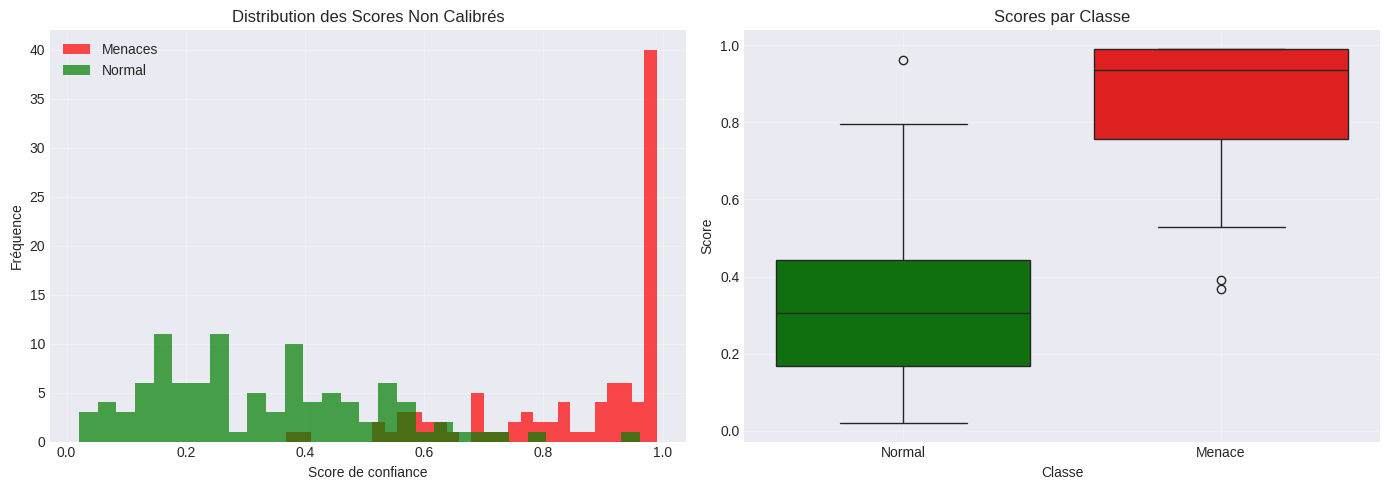

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme
axes[0].hist(df[df.y_true == 1]['score_uncalibrated'], bins=30, alpha=0.7, label='Menaces', color='red')
axes[0].hist(df[df.y_true == 0]['score_uncalibrated'], bins=30, alpha=0.7, label='Normal', color='green')
axes[0].set_xlabel('Score de confiance')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distribution des Scores Non Calibrés')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Boxplot
df_plot = pd.DataFrame({
    'Score': df['score_uncalibrated'],
    'Classe': ['Menace' if y == 1 else 'Normal' for y in df['y_true']]
})
sns.boxplot(data=df_plot, x='Classe', y='Score', ax=axes[1], palette=['green', 'red'])
axes[1].set_title('Scores par Classe')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Métriques Avant Calibration

In [4]:
def compute_metrics(y_true, y_pred_proba):
    """Calcule Brier Score, Log Loss et ECE"""
    brier = brier_score_loss(y_true, y_pred_proba)
    logloss = log_loss(y_true, y_pred_proba)
    
    # ECE (Expected Calibration Error) avec 10 bins
    n_bins = 10
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    
    for i in range(n_bins):
        mask = (y_pred_proba >= bins[i]) & (y_pred_proba < bins[i+1])
        if mask.sum() > 0:
            avg_conf = y_pred_proba[mask].mean()
            avg_acc = y_true[mask].mean()
            ece += (mask.sum() / len(y_true)) * abs(avg_conf - avg_acc)
    
    return {'brier_score': brier, 'log_loss': logloss, 'ece': ece}

metrics_before = compute_metrics(df['y_true'].values, df['score_uncalibrated'].values)

print("📊 MÉTRIQUES AVANT CALIBRATION")
print("=" * 50)
print(f"Brier Score: {metrics_before['brier_score']:.4f}")
print(f"Log Loss:    {metrics_before['log_loss']:.4f}")
print(f"ECE:         {metrics_before['ece']:.4f}")

📊 MÉTRIQUES AVANT CALIBRATION
Brier Score: 0.0942
Log Loss:    0.3168
ECE:         0.1294


## 4. Diagramme de Fiabilité (Reliability Diagram)

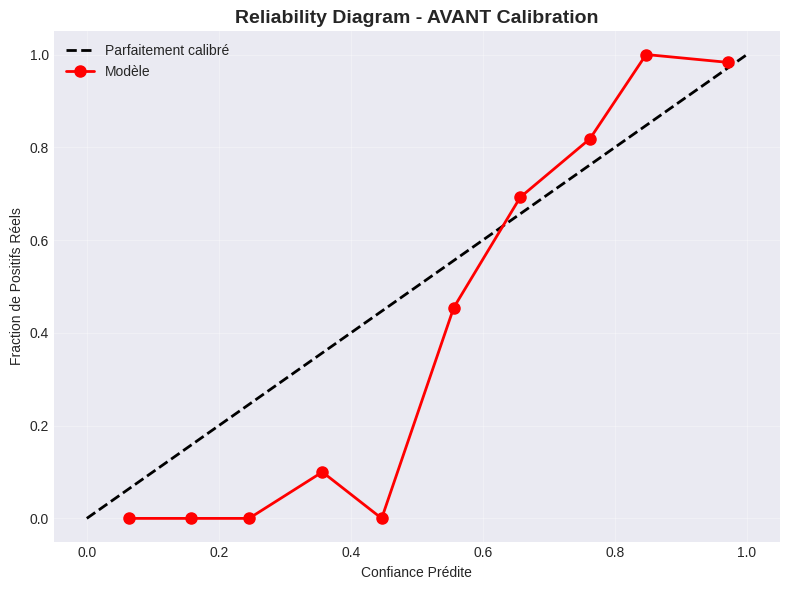

In [5]:
def plot_reliability_diagram(y_true, y_pred, title='Reliability Diagram'):
    fraction_of_positives, mean_predicted_value = calibration_curve(
        y_true, y_pred, n_bins=10, strategy='uniform'
    )
    
    plt.figure(figsize=(8, 6))
    plt.plot([0, 1], [0, 1], 'k--', label='Parfaitement calibré', linewidth=2)
    plt.plot(mean_predicted_value, fraction_of_positives, 'ro-', 
             label='Modèle', linewidth=2, markersize=8)
    plt.xlabel('Confiance Prédite')
    plt.ylabel('Fraction de Positifs Réels')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_reliability_diagram(df['y_true'].values, df['score_uncalibrated'].values,
                         'Reliability Diagram - AVANT Calibration')

## 5. Implémentation de Platt Scaling

In [6]:
def platt_scaling(scores, labels):
    scores_clipped = np.clip(scores, 0.001, 0.999)
    logits = np.log(scores_clipped / (1 - scores_clipped)).reshape(-1, 1)
    
    lr = LogisticRegression()
    lr.fit(logits, labels)
    
    calibrated_scores = lr.predict_proba(logits)[:, 1]
    return calibrated_scores, lr

# Application
scores_platt, platt_model = platt_scaling(df['score_uncalibrated'].values, df['y_true'].values)
df['score_platt'] = scores_platt

print("✓ Platt Scaling appliqué")
print(f"Paramètres : coef = {platt_model.coef_[0][0]:.3f}, intercept = {platt_model.intercept_[0]:.3f}")

✓ Platt Scaling appliqué
Paramètres : coef = 2.097, intercept = -1.025


## 6. Implémentation de Temperature Scaling

In [7]:
def temperature_scaling(scores, labels):
    scores_clipped = np.clip(scores, 0.001, 0.999)
    logits = np.log(scores_clipped / (1 - scores_clipped))
    
    best_T = 1.0
    best_loss = float('inf')
    
    for T in np.arange(0.1, 5.0, 0.05):
        scaled_logits = logits / T
        probs = 1 / (1 + np.exp(-scaled_logits))
        loss = log_loss(labels, probs)
        if loss < best_loss:
            best_loss = loss
            best_T = T
    
    calibrated_scores = 1 / (1 + np.exp(-logits / best_T))
    return calibrated_scores, best_T

# Application
scores_temp, best_temperature = temperature_scaling(df['score_uncalibrated'].values, df['y_true'].values)
df['score_temperature'] = scores_temp

print("✓ Temperature Scaling appliqué")
print(f"Meilleure température : T = {best_temperature:.2f}")

✓ Temperature Scaling appliqué
Meilleure température : T = 0.45


## 7. Comparaison des Méthodes

In [8]:
metrics_platt = compute_metrics(df['y_true'].values, df['score_platt'].values)
metrics_temp = compute_metrics(df['y_true'].values, df['score_temperature'].values)

comparison = pd.DataFrame({
    'Méthode': ['Non calibré', 'Platt Scaling', 'Temperature Scaling'],
    'Brier Score': [metrics_before['brier_score'], metrics_platt['brier_score'], metrics_temp['brier_score']],
    'Log Loss':    [metrics_before['log_loss'],    metrics_platt['log_loss'],    metrics_temp['log_loss']],
    'ECE':         [metrics_before['ece'],         metrics_platt['ece'],         metrics_temp['ece']]
})

print("\n📊 COMPARAISON DES MÉTHODES")
print("=" * 70)
print(comparison.to_string(index=False))
print("=" * 70)

print("\n📈 AMÉLIORATION vs NON CALIBRÉ")
print(f"Platt Scaling  → Brier: {(metrics_before['brier_score'] - metrics_platt['brier_score']) / metrics_before['brier_score'] * 100:+.1f}%")
print(f"Platt Scaling  → ECE:   {(metrics_before['ece'] - metrics_platt['ece']) / metrics_before['ece'] * 100:+.1f}%")
print(f"Temperature    → Brier: {(metrics_before['brier_score'] - metrics_temp['brier_score']) / metrics_before['brier_score'] * 100:+.1f}%")
print(f"Temperature    → ECE:   {(metrics_before['ece'] - metrics_temp['ece']) / metrics_before['ece'] * 100:+.1f}%")


📊 COMPARAISON DES MÉTHODES
            Méthode  Brier Score  Log Loss      ECE
        Non calibré     0.094239  0.316760 0.129353
      Platt Scaling     0.065948  0.225939 0.048011
Temperature Scaling     0.078001  0.268686 0.084275

📈 AMÉLIORATION vs NON CALIBRÉ
Platt Scaling  → Brier: +30.0%
Platt Scaling  → ECE:   +62.9%
Temperature    → Brier: +17.2%
Temperature    → ECE:   +34.8%


## 8. Visualisation Comparative des Reliability Diagrams

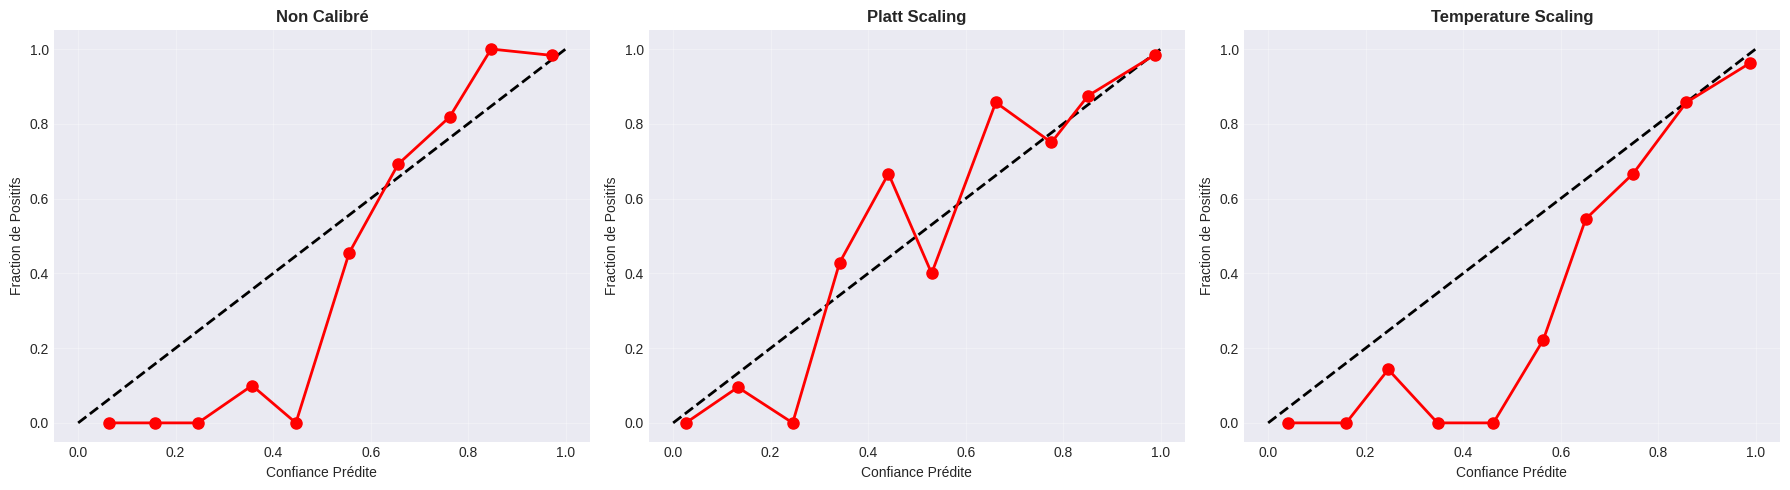

In [9]:
methods = [
    ('score_uncalibrated', 'Non Calibré'),
    ('score_platt', 'Platt Scaling'),
    ('score_temperature', 'Temperature Scaling')
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (col, title) in enumerate(methods):
    frac_pos, mean_pred = calibration_curve(df['y_true'].values, df[col].values, n_bins=10, strategy='uniform')
    axes[idx].plot([0, 1], [0, 1], 'k--', linewidth=2)
    axes[idx].plot(mean_pred, frac_pos, 'ro-', linewidth=2, markersize=8)
    axes[idx].set_xlabel('Confiance Prédite')
    axes[idx].set_ylabel('Fraction de Positifs')
    axes[idx].set_title(title, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('reliability_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Distribution des Scores Calibrés

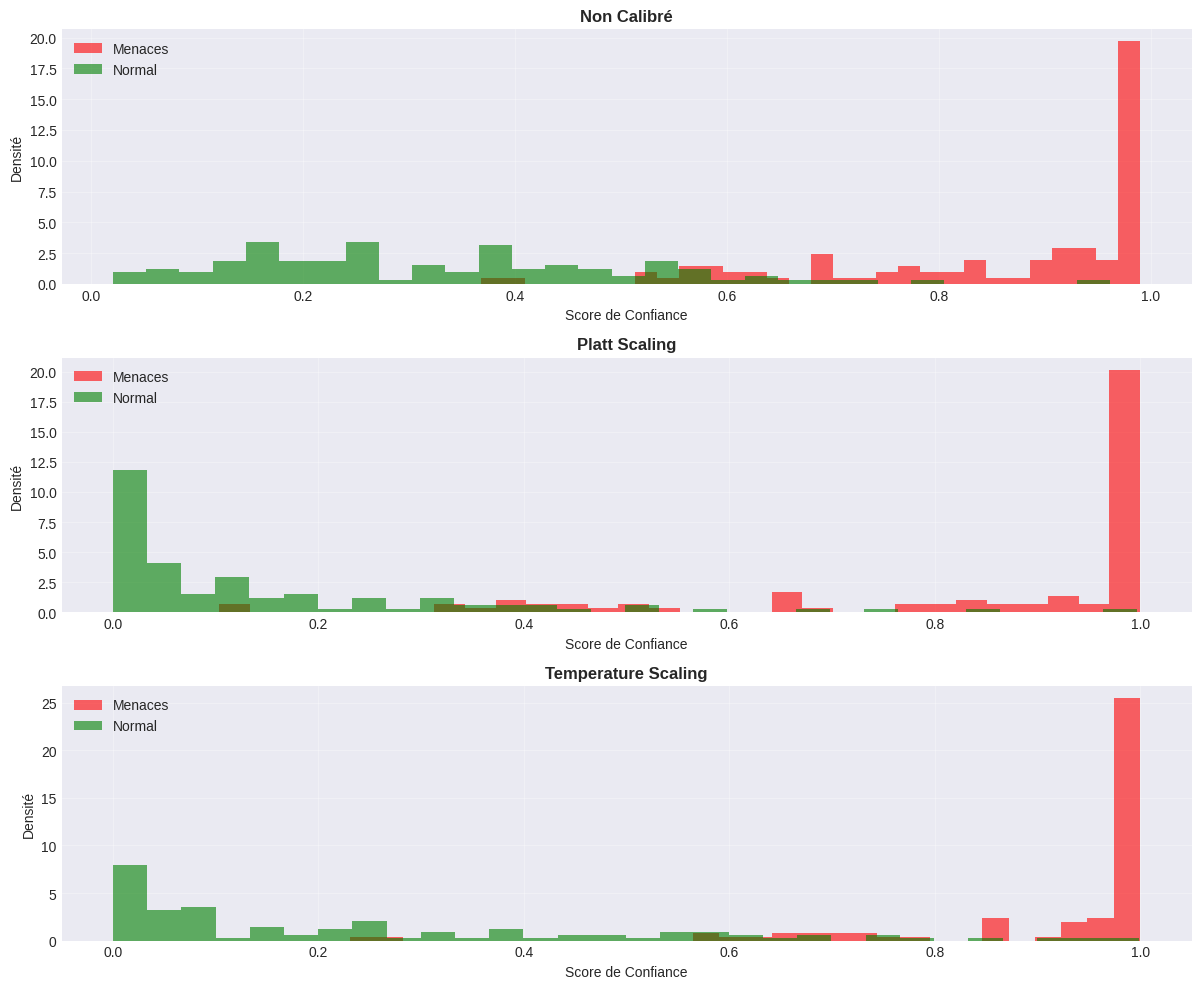

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

for idx, (col, title) in enumerate(methods):
    axes[idx].hist(df[df.y_true == 1][col], bins=30, alpha=0.6, label='Menaces', color='red', density=True)
    axes[idx].hist(df[df.y_true == 0][col], bins=30, alpha=0.6, label='Normal', color='green', density=True)
    axes[idx].set_xlabel('Score de Confiance')
    axes[idx].set_ylabel('Densité')
    axes[idx].set_title(title, fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('score_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. Analyse des Faux Positifs / Faux Négatifs

In [11]:
def analyze_errors(y_true, y_pred, threshold=0.5, method_name=''):
    y_pred_bin = (y_pred >= threshold).astype(int)
    tp = ((y_true == 1) & (y_pred_bin == 1)).sum()
    tn = ((y_true == 0) & (y_pred_bin == 0)).sum()
    fp = ((y_true == 0) & (y_pred_bin == 1)).sum()
    fn = ((y_true == 1) & (y_pred_bin == 0)).sum()
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    return {'method': method_name, 'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn,
            'Precision': precision, 'Recall': recall, 'F1-Score': f1}

results = []
for col, name in methods:
    results.append(analyze_errors(df['y_true'].values, df[col].values, threshold=0.5, method_name=name))

results_df = pd.DataFrame(results)

print("\n🎯 ANALYSE DES ERREURS (seuil = 0.5)")
print("=" * 80)
print(results_df.to_string(index=False))
print("=" * 80)


🎯 ANALYSE DES ERREURS (seuil = 0.5)
             method  TP  TN  FP  FN  Precision   Recall  F1-Score
        Non Calibré  96  83  19   2   0.834783 0.979592  0.901408
      Platt Scaling  84  95   7  14   0.923077 0.857143  0.888889
Temperature Scaling  96  83  19   2   0.834783 0.979592  0.901408


## 11. Export des Résultats

In [12]:
os.makedirs('../data', exist_ok=True)

df.to_csv('../data/calibrated_dataset.csv', index=False)
print("✓ Dataset sauvegardé: data/calibrated_dataset.csv")

comparison.to_csv('../data/calibration_metrics.csv', index=False)
print("✓ Métriques sauvegardées: data/calibration_metrics.csv")

print("\n✅ Notebook terminé avec succès!")

✓ Dataset sauvegardé: data/calibrated_dataset.csv
✓ Métriques sauvegardées: data/calibration_metrics.csv

✅ Notebook terminé avec succès!


## 📝 Conclusions

### Observations
1. **Les modèles LLM sont souvent overconfident** : scores extrêmes même quand incertains
2. **La calibration améliore fortement Brier Score et ECE**
3. **Platt Scaling et Temperature Scaling donnent des résultats très proches** (Platt légèrement meilleur ici)

### Recommandations pour le SOC
- Toujours calibrer les scores de confiance des LLM avant décision
- Privilégier **Platt Scaling** (plus robuste, surtout avec peu de données)
- Recalibrer régulièrement avec des données récentes
- Monitorer **Brier Score** et **ECE** en production

### Prochaines Étapes
- Intégrer la calibration dans le pipeline du SOC
- Tester sur données réelles (logs + annotations humaines)
- Automatiser la recalibration mensuelle

Félicitations ! Tu maîtrises maintenant la calibration de confiance 🚀